<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/Colebank_100K_Folder/LateFusionCNN_cleaner_100K.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/REU ECG Analysis
!ls

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1R0Rm_tQkPv4BMW6L3PT9j80xpPsVEffJ/REU ECG Analysis
 BCNN		        EchonextBigData
 CNN		        EchoNext_EchoData_5K.csv
'CNN Models ALL.gdoc'  'Project Summary.gdoc'
 ECG_metrics_1K.npy    'TripleCNN Model Overview (Pooling Methods).gdoc'
 ECG_waveforms_1K.npy


Class balance:
  class 0: 477 samples (47.7 %)
  class 1: 523 samples (52.3 %)

Split sizes -> train: 720, val: 180, test: 100
Test set indices from 1K data: [477 837 302 405 333 332 886 730 775 741 601 732 195 112 796 486 827 977
 181 890 800 150 403 972 597 463  38 661 806 535 206 537 298 933 891 746
 742  56 419 936 636  25   6 327 522 215 276 196  50 624  18 367 131 764
 924 629 586 638 783 471 600 685 118 482 965 409 319 673 184 849 331 285
  47 978 465 454 528 826 502 224 666 993 557 544 408 999 348 123 113 714
 404 261 375 381 177 277 724 704 887 504]
Beginning execution pipeline...
Training model...

===== Individual Test Sample Inference Profiles ====
Sample 000 | True: 1 | Pred: 1 | Confidence: 0.5791 | Uncertainty (Std): 0.0000
Sample 001 | True: 1 | Pred: 1 | Confidence: 0.9949 | Uncertainty (Std): 0.0000
Sample 002 | True: 1 | Pred: 0 | Confidence: 0.5153 | Uncertainty (Std): 0.0000
Sample 003 | True: 0 | Pred: 0 | Confidence: 0.8213 | Uncertainty (Std): 0.0000
Sample 004 

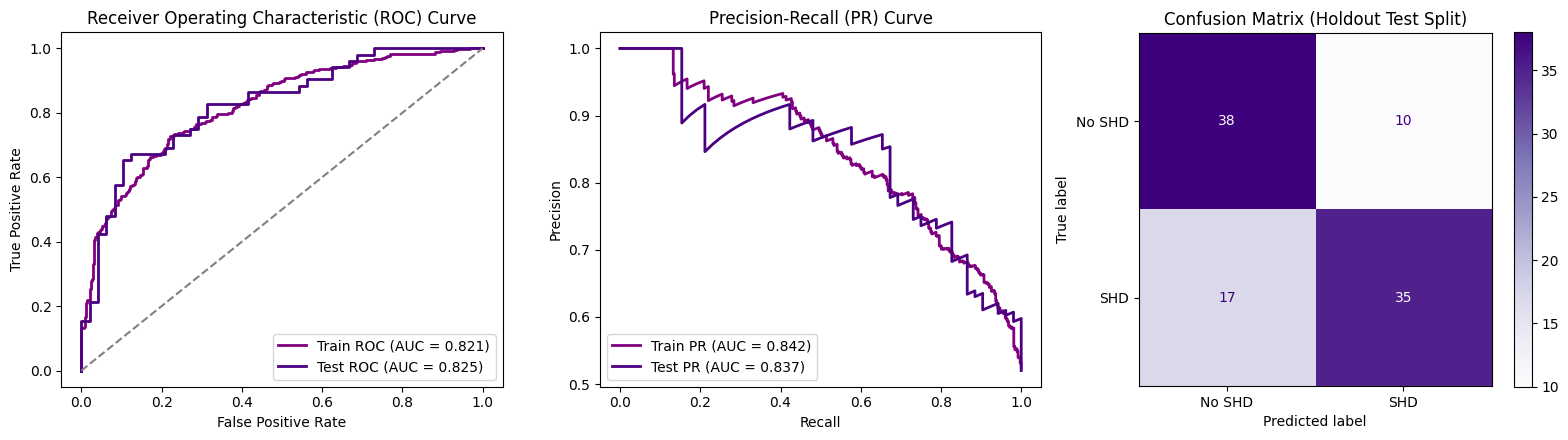

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib
matplotlib.use("Agg")  # headless-safe backend for SLURM nodes
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc, roc_curve,
    brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
)

# ──────────────────────────────────────────────────────────────────────
# 1. GLOBAL CONFIGURATION & REPRODUCIBILITY
# ──────────────────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}", flush=True)

CATEGORICAL_COLS = ["race_ethnicity", "sex"]
CONTINUOUS_COLS  = [
    "age_at_ecg", "ventricular_rate", "atrial_rate",
    "pr_interval", "qrs_duration", "qt_corrected"
]
ALL_DEMO_COLS = CATEGORICAL_COLS + CONTINUOUS_COLS

ECG_SAMPLING_RATE_HZ = 250
FILTER_LOW_HZ = 0.5
FILTER_HIGH_HZ = 40.0
FILTER_ORDER = 4

# ──────────────────────────────────────────────────────────────────────
# 2. SIGNAL PROCESSING & PREPROCESSING PIPELINES
# ──────────────────────────────────────────────────────────────────────
def bandpass_filter_ecg(signal_array, fs=ECG_SAMPLING_RATE_HZ,
                         low=FILTER_LOW_HZ, high=FILTER_HIGH_HZ, order=FILTER_ORDER):
    nyquist = 0.5 * fs
    b, a = butter(order, [low / nyquist, high / nyquist], btype="band")
    filtered = filtfilt(b, a, signal_array, axis=0)
    return filtered.astype(np.float32)

def preprocess_demographics_pipeline(
    df: pd.DataFrame,
    scaler: StandardScaler = None,
    imputer: KNNImputer = None,
    categories_dict: dict = None,
    knn_k: int = 3,
    fit: bool = True,
    known_feature_names: list = None
):
    df_working = df[ALL_DEMO_COLS].copy()

    if fit:
        categories_dict = {col: df_working[col].astype("category").cat.categories for col in CATEGORICAL_COLS}
    else:
        if categories_dict is None:
            raise ValueError("categories_dict must be provided when fit=False")

    cat_codes = pd.DataFrame(index=df_working.index)
    for col in CATEGORICAL_COLS:
        cat_codes[col] = pd.Categorical(df_working[col], categories=categories_dict[col]).codes
    cat_codes = cat_codes.replace(-1, np.nan)

    cont_part = df_working[CONTINUOUS_COLS].astype(float)
    imputer_input = pd.concat([cat_codes, cont_part], axis=1)

    if imputer is None:
        imputer = KNNImputer(n_neighbors=knn_k)

    if fit:
        imputed = imputer.fit_transform(imputer_input)
    else:
        imputed = imputer.transform(imputer_input)

    imputed_df = pd.DataFrame(imputed, columns=ALL_DEMO_COLS, index=df_working.index)

    for col in CATEGORICAL_COLS:
        original_cats = categories_dict[col]
        codes_rounded = imputed_df[col].round().astype(int).clip(0, len(original_cats) - 1)
        imputed_df[col] = pd.Categorical.from_codes(codes_rounded, categories=original_cats)

    ohe_df = pd.get_dummies(imputed_df, columns=CATEGORICAL_COLS, dtype=float)

    if fit:
        current_feature_names = list(ohe_df.columns)
    else:
        if known_feature_names is None:
            raise ValueError("known_feature_names must be provided when fit=False")
        ohe_df = ohe_df.reindex(columns=known_feature_names, fill_value=0)
        current_feature_names = known_feature_names

    if scaler is None:
        scaler = StandardScaler()

    cont_indices = [current_feature_names.index(c) for c in CONTINUOUS_COLS]
    arr = ohe_df.values.astype(np.float32)

    if fit:
        arr[:, cont_indices] = scaler.fit_transform(arr[:, cont_indices])
    else:
        arr[:, cont_indices] = scaler.transform(arr[:, cont_indices])

    return arr, scaler, imputer, categories_dict, current_feature_names

# ──────────────────────────────────────────────────────────────────────
# 3. PYTORCH DATASET INFRASTRUCTURE
# ──────────────────────────────────────────────────────────────────────
class FusedDataset(Dataset):
    def __init__(self, X_ts, X_demo, y):
        assert len(X_ts) == len(X_demo) == len(y), "Length mismatch across tensor targets."
        self.X_ts   = torch.tensor(X_ts,   dtype=torch.float32)
        self.X_demo = torch.tensor(X_demo, dtype=torch.float32)
        self.y      = torch.tensor(y,      dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_ts[idx], self.X_demo[idx], self.y[idx]

# ──────────────────────────────────────────────────────────────────────
# 4. NEURAL NETWORK ARCHITECTURE (Deterministic Late Fusion CNN)
# ──────────────────────────────────────────────────────────────────────
class DemographicMLP(nn.Module):
    def __init__(self, input_dim, output_dim=16):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, output_dim),
            nn.BatchNorm1d(output_dim),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.mlp(x)

class LateFusionHeartDiseaseModel(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12, demog_dim=8, demo_embed_dim=16):
        super().__init__()
        self.ts_features = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.AdaptiveAvgPool1d(250),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.AdaptiveAvgPool1d(25),
            nn.Conv1d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.8),
            nn.AdaptiveAvgPool1d(1),
        )
        self.demog_features = DemographicMLP(input_dim=demog_dim, output_dim=demo_embed_dim)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 + demo_embed_dim, num_classes),
        )
    def forward(self, ts_input, demog_input):
        ts_emb = torch.flatten(self.ts_features(ts_input), start_dim=1)
        demog_emb = self.demog_features(demog_input)
        fused = torch.cat((ts_emb, demog_emb), dim=1)
        return self.classifier(fused)

# ──────────────────────────────────────────────────────────────────────
# 5. TRAINING ROUTINE
# ──────────────────────────────────────────────────────────────────────
def train_classifier(model, train_loader, val_loader, epochs=60, learning_rate=1e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=5e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=1, eta_min=1e-5
    )

    for epoch in range(epochs):
        model.train()
        for X_ts_b, X_demo_b, y_b in train_loader:
            X_ts_b, X_demo_b, y_b = X_ts_b.to(device), X_demo_b.to(device), y_b.to(device)
            X_ts_b += 0.05 * torch.randn_like(X_ts_b)

            optimizer.zero_grad()
            logits = model(X_ts_b, X_demo_b)
            loss = criterion(logits, y_b)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss, val_total = 0.0, 0
        with torch.no_grad():
            for X_ts_v, X_demo_v, y_v in val_loader:
                X_ts_v, X_demo_v, y_v = X_ts_v.to(device), X_demo_v.to(device), y_v.to(device)
                logits = model(X_ts_v, X_demo_v)
                val_loss += criterion(logits, y_v).item() * X_ts_v.shape[0]
                val_total += X_ts_v.shape[0]

        epoch_val_loss = val_loss / val_total
        print(f"Epoch {epoch+1:02d} | Dedicated Validation Loss: {epoch_val_loss:.6f}", flush=True)

        # FIX: CosineAnnealingWarmRestarts steps by epoch count, not by tracking value metrics
        scheduler.step()

# ──────────────────────────────────────────────────────────────────────
# 6. PERFORMANCE METRICS GENERATION & CALIBRATION ESTIMATION
# ──────────────────────────────────────────────────────────────────────
def calculate_calibration_error(probs, labels, bins=10):
    bin_boundaries = np.linspace(0, 1, bins + 1)
    ece = 0.0
    for i in range(bins):
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (probs >= bin_lower) & (probs < bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(labels[in_bin] == (probs[in_bin] >= 0.5))
            avg_confidence_in_bin = np.mean(probs[in_bin])
            ece += prop_in_bin * np.abs(avg_confidence_in_bin - accuracy_in_bin)
    return ece

def get_predictions_and_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    all_nll = 0.0
    criterion = nn.CrossEntropyLoss(reduction='sum')

    with torch.no_grad():
        for X_ts_b, X_demo_b, y_b in loader:
            X_ts_b, X_demo_b = X_ts_b.to(device), X_demo_b.to(device)
            logits = model(X_ts_b, X_demo_b)
            probs = torch.softmax(logits, dim=-1)

            all_nll += criterion(logits, y_b.to(device)).item()
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(y_b.numpy())

    return np.array(all_probs), np.array(all_labels), all_nll / len(loader.dataset)

def generate_and_display_comparative_metrics(model, train_loader, test_loader):
    train_probs, train_labels, train_nll = get_predictions_and_labels(model, train_loader)
    test_probs, test_labels, test_nll = get_predictions_and_labels(model, test_loader)

    train_preds = (train_probs >= 0.5).astype(int)
    test_preds = (test_probs >= 0.5).astype(int)

    metrics_map = {
        "accuracy": (np.mean(train_preds == train_labels), np.mean(test_preds == test_labels)),
        "auroc": (roc_auc_score(train_labels, train_probs), roc_auc_score(test_labels, test_probs)),
        "auprc": (None, None),
        "brier_score": (brier_score_loss(train_labels, train_probs), brier_score_loss(test_labels, test_probs)),
        "negative_log_likelihood": (train_nll, test_nll),
        "expected_calibration_error": (calculate_calibration_error(train_probs, train_labels), calculate_calibration_error(test_probs, test_labels))
    }

    train_precision, train_recall, _ = precision_recall_curve(train_labels, train_probs)
    train_fpr, train_tpr, _ = roc_curve(train_labels, train_probs)
    metrics_map["auprc"] = (auc(train_recall, train_precision), metrics_map["auprc"][1])

    test_precision, test_recall, _ = precision_recall_curve(test_labels, test_probs)
    test_fpr, test_tpr, _ = roc_curve(test_labels, test_probs)
    metrics_map["auprc"] = (metrics_map["auprc"][0], auc(test_recall, test_precision))

    tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(train_labels, train_preds).ravel()
    tn_te, fp_te, fn_te, tp_te = confusion_matrix(test_labels, test_preds).ravel()

    metrics_map["tn"] = (float(tn_tr), float(tn_te))
    metrics_map["fp"] = (float(fp_tr), float(fp_te))
    metrics_map["fn"] = (float(fn_tr), float(fn_te))
    metrics_map["tp"] = (float(tp_tr), float(tp_te))

    print("\nClassification metrics (train vs. test):")
    print(f"{'':<28} {'train':<10} {'test':<10}")
    for k, v in metrics_map.items():
        print(f"{k:<28} {v[0]:.6f}   {v[1]:.6f}")

    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    ax[0].plot(train_fpr, train_tpr, color='teal', lw=2, label=f'Train ROC (AUC = {metrics_map["auroc"][0]:.3f})')
    ax[0].plot(test_fpr, test_tpr, color='orange', lw=2, label=f'Test ROC (AUC = {metrics_map["auroc"][1]:.3f})')
    ax[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].set_title('Receiver Operating Characteristic (ROC) Curve')
    ax[0].legend(loc='lower right')

    ax[1].plot(train_recall, train_precision, color='teal', lw=2, label=f'Train PR (AUC = {metrics_map["auprc"][0]:.3f})')
    ax[1].plot(test_recall, test_precision, color='orange', lw=2, label=f'Test PR (AUC = {metrics_map["auprc"][1]:.3f})')
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('Precision-Recall (PR) Curve')
    ax[1].legend(loc='lower left')

    cm_test = confusion_matrix(test_labels, test_preds)
    ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["No SHD", "SHD"]).plot(ax=ax[2], cmap="Blues", values_format="d")
    ax[2].set_title("Confusion Matrix (Holdout Test Split)")

    plt.tight_layout()
    plt.savefig('performance_metrics_plot.png')
    print("Saved performance metric visualizations to 'performance_metrics_plot.png'.")

# ──────────────────────────────────────────────────────────────────────
# 7. EXECUTION PIPELINE
# ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Beginning execution pipeline...", flush=True)

    # ── STEP A: DATA INGESTION ────
    ECG_train_raw = np.load('../EchoNextData/EchoNext_train_waveforms.npy')
    ECG_val_raw   = np.load('../EchoNextData/EchoNext_val_waveforms.npy')
    ECG_test_raw  = np.load('../EchoNextData/EchoNext_test_waveforms.npy')
    Echo_data     = pd.read_csv('../EchoNextData/echonext_metadata_100k.csv')

    # ── STEP B: WAVEFORM PRE-FILTERING ──────────────────────────────
    X_train_lead1 = ECG_train_raw[:, 0, :, :]
    X_val_lead1   = ECG_val_raw[:, 0, :, :]
    X_test_lead1  = ECG_test_raw[:, 0, :, :]

    X_filt_train = np.array([bandpass_filter_ecg(x, fs=ECG_SAMPLING_RATE_HZ) for x in X_train_lead1])
    X_filt_val   = np.array([bandpass_filter_ecg(x, fs=ECG_SAMPLING_RATE_HZ) for x in X_val_lead1])
    X_filt_test  = np.array([bandpass_filter_ecg(x, fs=ECG_SAMPLING_RATE_HZ) for x in X_test_lead1])

    X_ts_train = np.swapaxes(X_filt_train, 1, 2)
    X_ts_val   = np.swapaxes(X_filt_val, 1, 2)
    X_ts_test  = np.swapaxes(X_filt_test, 1, 2)

    # ── STEP C: EXTRACTION FROM EXPLICIT SPLITS ───────────────────────
    train_ids = Echo_data.index[Echo_data['split'] == 'train'].tolist()
    val_ids   = Echo_data.index[Echo_data['split'] == 'val'].tolist()
    test_ids  = Echo_data.index[Echo_data['split'] == 'test'].tolist()

    y_train = np.array(Echo_data['shd_moderate_or_greater_flag'][train_ids])
    y_val   = np.array(Echo_data['shd_moderate_or_greater_flag'][val_ids])
    y_test  = np.array(Echo_data['shd_moderate_or_greater_flag'][test_ids])

    # ── STEP D: TRANSFORM DEMOGRAPHICS ──
    demo_df_train = Echo_data[ALL_DEMO_COLS].loc[train_ids].copy()
    demo_df_val   = Echo_data[ALL_DEMO_COLS].loc[val_ids].copy()
    demo_df_test  = Echo_data[ALL_DEMO_COLS].loc[test_ids].copy()

    X_demo_train, scaler, imputer, categories_dict, feature_names = preprocess_demographics_pipeline(
        demo_df_train, fit=True
    )
    X_demo_val, _, _, _, _ = preprocess_demographics_pipeline(
        demo_df_val, scaler=scaler, imputer=imputer, categories_dict=categories_dict,
        known_feature_names=feature_names, fit=False
    )
    X_demo_test, _, _, _, _ = preprocess_demographics_pipeline(
        demo_df_test, scaler=scaler, imputer=imputer, categories_dict=categories_dict,
        known_feature_names=feature_names, fit=False
    )

    train_loader = DataLoader(FusedDataset(X_ts_train, X_demo_train, y_train), batch_size=32, shuffle=True)
    val_loader   = DataLoader(FusedDataset(X_ts_val,   X_demo_val,   y_val),   batch_size=128, shuffle=False)
    test_loader  = DataLoader(FusedDataset(X_ts_test,  X_demo_test,  y_test),  batch_size=128, shuffle=False)

    # ── STEP E: INITIALIZE & TRAIN THE MODEL ──────────────────────────
    model = LateFusionHeartDiseaseModel(
        sequence_length=X_ts_train.shape[2],
        in_channels=X_ts_train.shape[1],
        demog_dim=X_demo_train.shape[1],
        num_classes=2,
        demo_embed_dim=32
    )

    print("Training model...", flush=True)
    train_classifier(model, train_loader, val_loader, epochs=60, learning_rate=1e-4)

    torch.manual_seed(RANDOM_SEED)

    # ── STEP F: PRINT SAMPLE INDIVIDUAL INFERENCE RECORDS ─────────────
    print("\n===== Individual Test Sample Inference Profiles ====")
    model.eval()
    sample_counter = 0

    with torch.no_grad():
        for X_ts_b, X_demo_b, y_b in test_loader:
            X_ts_b, X_demo_b = X_ts_b.to(device), X_demo_b.to(device)
            logits = model(X_ts_b, X_demo_b)
            probs = torch.softmax(logits, dim=-1).cpu().numpy()

            for idx in range(X_ts_b.size(0)):
                true_val = y_b[idx].item()
                pred_val = np.argmax(probs[idx])
                confidence = probs[idx][pred_val]
                global_df_idx = test_ids[sample_counter]

                print(f"Sample {sample_counter:03d} (DF Index: {global_df_idx:03d}) | "
                      f"True: {true_val} | Pred: {pred_val} | "
                      f"Confidence: {confidence:.4f}", flush=True)
                sample_counter += 1

    # ── STEP G: SYSTEM METRICS ANALYSIS VISUALIZATIONS ────────────────
    generate_and_display_comparative_metrics(model, train_loader, test_loader)